# EP11 — Knowledge Graphs: RDF/OWL Reasoning & TransE
**COMPSCI 713 · S1 2025 Q2 · 3 marks**

| Part | Topic | Marks |
|------|-------|-------|
| a | OWL inference chain from RDF triples | 1 |
| b | TransE embedding — who is more likely involved? | 2 |

---

## Background: Two Approaches to Knowledge Graphs

### Approach 1 — Symbolic: RDF/OWL
Facts are stored as **triples**: (subject, predicate, object)
- e.g., `(Alice, involved_in, FraudCase_1)`
- Reasoning: OWL rules fire when conditions are met → infer new facts
- **Strength:** transparent, explainable, exact
- **Weakness:** cannot handle incomplete/noisy data; can't infer beyond defined rules

### Approach 2 — Embedding: TransE
Each entity and relation is a **vector** in ℝᵈ.
- Core assumption: `h + r ≈ t` for true triples (head + relation ≈ tail)
- To find likely tail: find entity `t` that minimises `‖h + r − t‖`
- **Strength:** handles incomplete KGs, generalises to unseen patterns
- **Weakness:** less interpretable than symbolic rules

---

## Part (a) — OWL Inference Chain [1 mark]

**RDF triples:**
```
(Alice,       involved_in,  FraudCase_1)
(FraudCase_1, occurred_at,  OffshoreBank)
(OffshoreBank, located_in,  CaymanIslands)
```

**OWL rule:** "If a person is involved in a case that occurred in a high-risk country, they are a high-risk individual."

**Ontology fact:** `CaymanIslands is a HighRiskCountry`

**Inference chain:**
```
1. CaymanIslands  → type: HighRiskCountry            (ontology definition)
2. OffshoreBank   → located_in → HighRiskCountry     (from triple 3)
3. FraudCase_1    → occurred_at → OffshoreBank       (from triple 2)
                   therefore: FraudCase_1 occurred in a HighRiskCountry
4. Alice          → involved_in → FraudCase_1        (from triple 1)
                   therefore: Alice is involved in a case in a HighRiskCountry
5. OWL rule fires → Alice is a HighRiskIndividual    ← NEW FACT
```

**New fact inferred:** `(Alice, rdf:type, HighRiskIndividual)`

---

## Part (b) — TransE Calculation [2 marks]

**Embeddings:**
| Entity/Relation | Embedding (2D) |
|----------------|----------------|
| Alice           | (0.8, 0.2)    |
| Bob             | (0.3, 0.5)    |
| FraudCase_99    | (0.9, 0.3)    |
| involved_in     | (0.1, 0.1)    |

**TransE: h + r ≈ t, so find person p where ‖p + r − FraudCase_99‖ is smallest**

**For Alice:**
```
Alice + involved_in = (0.8+0.1, 0.2+0.1) = (0.9, 0.3)
FraudCase_99        = (0.9, 0.3)
Distance = ‖(0.9−0.9, 0.3−0.3)‖ = ‖(0.0, 0.0)‖ = 0.00
```

**For Bob:**
```
Bob + involved_in = (0.3+0.1, 0.5+0.1) = (0.4, 0.6)
FraudCase_99      = (0.9, 0.3)
Distance = ‖(0.4−0.9, 0.6−0.3)‖ = ‖(−0.5, 0.3)‖ = √(0.25+0.09) = √0.34 ≈ 0.583
```

**Alice has distance 0.00 vs Bob's 0.58 → Alice is far more likely to be involved in FraudCase_99**

**Why embedding-based reasoning is useful here:**  
The system never explicitly stored `(Alice, involved_in, FraudCase_99)`. This is a *new, unseen case*. TransE infers the likely link purely from the geometric structure of learned embeddings — it generalises to incomplete knowledge graphs without needing a handwritten rule for every possible case.

---

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =============================================================
# TransE calculation from the exam
# =============================================================

entities = {
    'Alice':       np.array([0.8, 0.2]),
    'Bob':         np.array([0.3, 0.5]),
    'FraudCase_99': np.array([0.9, 0.3]),
}
relations = {
    'involved_in': np.array([0.1, 0.1]),
}

target = entities['FraudCase_99']
r      = relations['involved_in']

print('=== TransE: h + r ≈ t ===')
print(f'Target: FraudCase_99 = {target}')
print(f'Relation: involved_in = {r}')
print()

for name in ['Alice', 'Bob']:
    h = entities[name]
    predicted_t = h + r
    diff = predicted_t - target
    dist = np.linalg.norm(diff)
    print(f'{name}:')
    print(f'  h + r = {h} + {r} = {predicted_t}')
    print(f'  ||predicted − FraudCase_99|| = ||{diff}|| = {dist:.4f}')
    print()

print('Winner (smallest distance = most likely relationship):')
dists = {name: np.linalg.norm((entities[name] + r) - target) for name in ['Alice', 'Bob']}
winner = min(dists, key=dists.get)
print(f'  → {winner} (dist={dists[winner]:.4f})')

=== TransE: h + r ≈ t ===
Target: FraudCase_99 = [0.9 0.3]
Relation: involved_in = [0.1 0.1]

Alice:
  h + r = [0.8 0.2] + [0.1 0.1] = [0.9 0.3]
  ||predicted − FraudCase_99|| = ||[0.00000000e+00 5.55111512e-17]|| = 0.0000

Bob:
  h + r = [0.3 0.5] + [0.1 0.1] = [0.4 0.6]
  ||predicted − FraudCase_99|| = ||[-0.5  0.3]|| = 0.5831

Winner (smallest distance = most likely relationship):
  → Alice (dist=0.0000)


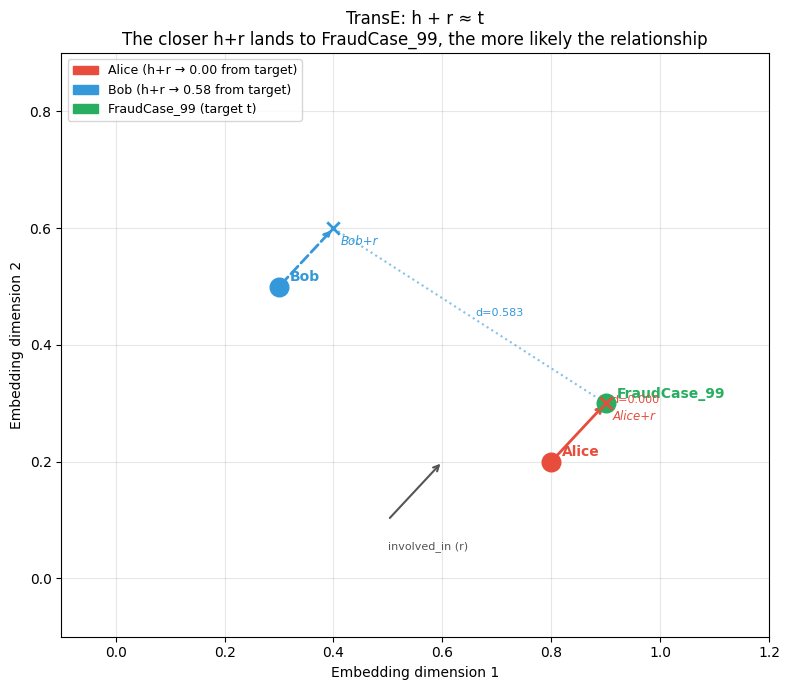

In [3]:
# =============================================================
# Visualisation: TransE geometry in 2D embedding space
# =============================================================
fig, ax = plt.subplots(figsize=(8, 7))

colours = {'Alice': '#e74c3c', 'Bob': '#3498db',
           'FraudCase_99': '#27ae60', 'involved_in': '#95a5a6'}

# Draw entity points
for name, vec in entities.items():
    ax.scatter(*vec, s=180, color=colours.get(name, 'gray'), zorder=5)
    ax.annotate(name, vec, textcoords='offset points', xytext=(8, 4),
                fontsize=10, fontweight='bold', color=colours.get(name, 'gray'))

# Draw h + r vectors for Alice and Bob
for name, colour, linestyle in [('Alice', '#e74c3c', '-'), ('Bob', '#3498db', '--')]:
    h = entities[name]
    predicted_t = h + r
    # Arrow from h to h+r
    ax.annotate('', xy=predicted_t, xytext=h,
                arrowprops=dict(arrowstyle='->', color=colour,
                                lw=2, linestyle=linestyle))
    ax.annotate(f'{name}+r', predicted_t, textcoords='offset points',
                xytext=(5, -12), fontsize=8.5, color=colour, style='italic')
    ax.scatter(*predicted_t, s=80, color=colour, marker='x', zorder=5, linewidths=2)

    # Distance line to FraudCase_99
    dist = np.linalg.norm(predicted_t - target)
    mid  = (predicted_t + target) / 2
    ax.plot([predicted_t[0], target[0]], [predicted_t[1], target[1]],
            color=colour, linestyle=':', alpha=0.6, linewidth=1.5)
    ax.text(mid[0]+0.01, mid[1], f'd={dist:.3f}', fontsize=8, color=colour)

# Relation vector legend
ax.annotate('', xy=(0.5 + r[0], 0.1 + r[1]), xytext=(0.5, 0.1),
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))
ax.text(0.5, 0.05, 'involved_in (r)', fontsize=8, color='#555')

ax.set_xlim(-0.1, 1.2)
ax.set_ylim(-0.1, 0.9)
ax.set_xlabel('Embedding dimension 1')
ax.set_ylabel('Embedding dimension 2')
ax.set_title('TransE: h + r ≈ t\nThe closer h+r lands to FraudCase_99, the more likely the relationship')
ax.grid(True, alpha=0.3)

legend_patches = [
    mpatches.Patch(color='#e74c3c', label='Alice (h+r → 0.00 from target)'),
    mpatches.Patch(color='#3498db', label='Bob (h+r → 0.58 from target)'),
    mpatches.Patch(color='#27ae60', label='FraudCase_99 (target t)'),
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

In [4]:
# =============================================================
# Demo: OWL-style forward chaining inference
# Simulates the symbolic reasoning in Part (a)
# =============================================================

# Knowledge base as a dict of sets
facts = {
    ('Alice',        'involved_in',  'FraudCase_1'),
    ('FraudCase_1',  'occurred_at',  'OffshoreBank'),
    ('OffshoreBank', 'located_in',   'CaymanIslands'),
    ('CaymanIslands','type',         'HighRiskCountry'),
}

def forward_chain(facts):
    """Apply OWL-style rules until no new facts can be derived."""
    new_facts = set(facts)
    log = []
    changed = True
    while changed:
        changed = False
        # Rule: if (Bank, located_in, Country) and (Country, type, HighRiskCountry)
        #       then (Bank, in_high_risk_country, True)
        for (a, p, b) in list(new_facts):
            if p == 'located_in':
                country = b
                if ('HighRiskCountry', 'is', country) in new_facts or \
                   (country, 'type', 'HighRiskCountry') in new_facts:
                    triple = (a, 'in_high_risk_country', 'True')
                    if triple not in new_facts:
                        new_facts.add(triple)
                        log.append(f'Rule 1 → {triple}')
                        changed = True

        # Rule: if (Case, occurred_at, Bank) and (Bank, in_high_risk_country, True)
        #       then (Case, in_high_risk_country, True)
        for (a, p, b) in list(new_facts):
            if p == 'occurred_at':
                bank = b
                if (bank, 'in_high_risk_country', 'True') in new_facts:
                    triple = (a, 'in_high_risk_country', 'True')
                    if triple not in new_facts:
                        new_facts.add(triple)
                        log.append(f'Rule 2 → {triple}')
                        changed = True

        # Rule: if (Person, involved_in, Case) and (Case, in_high_risk_country, True)
        #       then (Person, type, HighRiskIndividual)
        for (a, p, b) in list(new_facts):
            if p == 'involved_in':
                case = b
                if (case, 'in_high_risk_country', 'True') in new_facts:
                    triple = (a, 'type', 'HighRiskIndividual')
                    if triple not in new_facts:
                        new_facts.add(triple)
                        log.append(f'Rule 3 (OWL) → {triple}  ← NEW INFERRED FACT')
                        changed = True
    return new_facts, log

final_facts, inference_log = forward_chain(facts)

print('=== OWL Forward-Chaining Inference ===')
print('\nOriginal triples:')
for t in sorted(facts): print(f'  {t}')
print('\nInference steps:')
for step in inference_log: print(f'  {step}')
print('\nNew facts added to knowledge base:')
for t in final_facts - facts: print(f'  ★ {t}')

=== OWL Forward-Chaining Inference ===

Original triples:
  ('Alice', 'involved_in', 'FraudCase_1')
  ('CaymanIslands', 'type', 'HighRiskCountry')
  ('FraudCase_1', 'occurred_at', 'OffshoreBank')
  ('OffshoreBank', 'located_in', 'CaymanIslands')

Inference steps:
  Rule 1 → ('OffshoreBank', 'in_high_risk_country', 'True')
  Rule 2 → ('FraudCase_1', 'in_high_risk_country', 'True')
  Rule 3 (OWL) → ('Alice', 'type', 'HighRiskIndividual')  ← NEW INFERRED FACT

New facts added to knowledge base:
  ★ ('FraudCase_1', 'in_high_risk_country', 'True')
  ★ ('OffshoreBank', 'in_high_risk_country', 'True')
  ★ ('Alice', 'type', 'HighRiskIndividual')


## Exam Quick-Reference

**Part (a) — answer:** `(Alice, type, HighRiskIndividual)`  
Reasoning chain: CaymanIslands→HighRiskCountry → OffshoreBank in HighRiskCountry → FraudCase_1 in HighRiskCountry → Alice (involved_in) → HighRiskIndividual

**Part (b) — TransE formula:** `score(h,r,t) = −‖h + r − t‖`
- Alice: ‖(0.8+0.1, 0.2+0.1) − (0.9,0.3)‖ = ‖(0,0)‖ = **0.00**
- Bob:   ‖(0.3+0.1, 0.5+0.1) − (0.9,0.3)‖ = ‖(−0.5,0.3)‖ ≈ **0.58**
- **Alice is more likely to be involved**

**Why TransE is useful:** handles *incomplete* knowledge graphs — infers plausible links that were never explicitly stored, generalises to new entities/cases.